## The Future Is Not a Feature: A Look-Ahead Bias-Free Evaluation Framework for Startup Success Prediction through Machine Learning

In [1]:
%load_ext autoreload
%autoreload 2

import os
from dotenv import load_dotenv 
import yaml

import pandas as pd
import polars as pl
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import RandomUnderSampler

from src.preprocessing import preprocessDataset,getCompleteDatasetWithTimeWindow, getCompleteDatasetWithoutTimeWindow
from src.utils import plot_correlation_heatmap, to_tensors, get_probs, plot_shap_comparison, compute_wilcoxon_table, set_seed,compare_metrics, make_nested_subsampler, plot_learning_curves


from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from src.models.MLP import MLP
from tabpfn_client import init, TabPFNClassifier


from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score, roc_auc_score)
import wandb
import shap
import matplotlib.pyplot as plt 


import scipy.integrate
if not hasattr(np, 'trapz'):
    np.trapz = scipy.integrate.trapezoid

load_dotenv()

with open('config/config.yaml', 'r') as f:
    config = yaml.safe_load(f)


timeWindow=int(config['time_window'])

lastYear=int(config['last_year'])

shap_store = {}
metrics_store = {}
learning_curve_store = {}

/home/giulio-casti/Scrivania/UNICA/DOTTORATO/startup-survival-TabPFN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Dataset creation

Include all the steps of the feature and target engineering starting from the panel dataset. 

The original initial panel cannot be released. In _data/raw/panel_example.csv_  there is an example with few records.

Loading of the initial panel and university ranking

In [ ]:
# initialPanel = pl.read_csv(config['paths']['raw_dataset'], null_values=["NA"])

# university_ranking_path = config['paths']['raw_university_ranking']

## Dataset with time window (no look-ahead bias)
Already available in _data/processed/dataset_window.csv_

In [ ]:
# datasetWithTimeWindow = getCompleteDatasetWithTimeWindow(initialPanel,timeWindow,lastYear)

# dataset_window = preprocessDataset(datasetWithTimeWindow,university_ranking_path)

# dataset_window.write_csv(config["paths"]["dataset_window"])

# print("Dataset with time window saved to:", config['paths']['dataset_window'])

## Dataset without time window (with look ahead bias)
Already available in _data/processed/dataset_nowindow.csv_

In [ ]:
# # need to re-run the previous cell to get dataset_window before running the following code, to ensure that 
# # the firm in the dataset without time window are the same as those in the dataset with time window

# datasetWithNoTimeWindow = getCompleteDatasetWithoutTimeWindow(initialPanel,dataset_window)

# dataset_nowindow = preprocessDataset(datasetWithNoTimeWindow,university_ranking_path,flag_no_time_window=True)

# # to ensure that the firm in the dataset without time window are the same as those in the dataset with time window, we select only those that are present in the dataset with time window (we must keep the same columns and rows in all the experiments to make them comparable)
# dataset_nowindow = dataset_nowindow.select(dataset_window.columns)

# dataset_nowindow.write_csv(config["paths"]["dataset_nowindow"])

# print("Dataset without time window saved to:", config['paths']['dataset_nowindow'])

## Multiclass dataset with time window (no look-ahead bias)
Already available in _data/processed/dataset_window_multi.csv_

In [ ]:
# datasetWithTimeWindow = getCompleteDatasetWithTimeWindow(initialPanel,timeWindow,lastYear)

# dataset_window = preprocessDataset(datasetWithTimeWindow,university_ranking_path,multiclass=True)

# dataset_window.write_csv(config["paths"]["dataset_window_multi"])

# print("Dataset with time window saved to:", config['paths']['dataset_window_multi'])

## Dataset selection:
(choose one)

Bias controlled experiment

In [2]:
dataset = pd.read_csv(config["paths"]["dataset_window"])
tag="window"

No window experiment (look-ahead bias)

In [ ]:
dataset = pd.read_csv(config["paths"]["dataset_nowindow"])
tag="nowindow"

Multiclass dataset

In [ ]:
dataset = pd.read_csv(config["paths"]["dataset_window_multi"])
tag="multi"

No Team experiment

In [ ]:
dataset = pd.read_csv(config["paths"]["dataset_window"])
dataset = dataset.drop(columns= [
    "Total_People",
    "WorkExp_Idx_Mean",
    "Highest_Degree_Mean",
    "Total_Founders",
    "Percent_Females",
    "Avg_Earliest_Year",
    "HasTop50Institute",
    "Is_Eco",
    "Is_Eng",
    "Is_NS",
    "Is_Hum",
    "Is_SS",
    "Is_Med",
    "Is_Law",
    "Is_IT",
    "WorkExperienceIndex_CEO",
    "Gender_CEO_Female"
])
tag="noteam"

No Competitors experiment

In [ ]:
dataset = pd.read_csv(config["paths"]["dataset_window"])
dataset = dataset.drop(columns=['SimilarityScoreMean', 'N_Competitors', 'Same_Country'])
tag="nocompetitors"

Feature correlation

In [ ]:
corr_matrix = plot_correlation_heatmap(dataset)

## Split, Imputation and Scaling

Run for each experiment

In [3]:
ids = dataset['CompanyID'] 
X = dataset.drop(['CompanyID', 'Target'],axis=1)
y = dataset['Target']

rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)



# Split: 60% train, 20% validation (threshold tuning), 20% test (final evaluation)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=config['test_size'],stratify=y, random_state=config['random_seed'])


# X_train, y_train = rus.fit_resample(X_train, y_train)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=config['random_seed']) 

imputer = KNNImputer(n_neighbors=5)
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)


scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled   = scaler.transform(X_val_imp)
X_test_scaled  = scaler.transform(X_test_imp)

print(f"Total: {len(y)} | Train: {len(y_train)} | Validation: {len(y_val)} | Test: {len(y_test)}")

# Subsampler annidato/stratificato del train pool per le learning curve.
subsample_train = make_nested_subsampler(y_train, config['random_seed'])

Total: 30297 | Train: 18178 | Validation: 6059 | Test: 6060


## Sweep creation

In [4]:

entity=os.getenv("entity")
project=os.getenv("project")

# Initialize a new sweep
sweep_id = wandb.sweep(config["sweep_settings"],entity=entity, project=project)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/giulio-casti/.netrc.


Create sweep with ID: jog5nux1
Sweep URL: https://wandb.ai/giuliocasti-universit-degli-studi-di-cagliari/TabPFN/sweeps/jog5nux1



Definition of the training function to be called by wandb agent.

It will be called multiple times by the wandb agent, each time with a different set of hyperparameters defined in the sweep configuration.

The function trains the specified model, evaluates it on the validation and test sets, logs metrics and plots to Weights & Biases, and computes SHAP values for interpretability.

The _tag_ parameter is used to differentiate between different dataset versions (e.g., with or without time window) when storing SHAP values for later comparison.

In [5]:
def make_train(tag=None):
    def train():
        with wandb.init():
            wandb_config = wandb.config

            # Reproducibility: seed Python, NumPy, PyTorch (CPU+CUDA), cuDNN.
            # Sklearn / LightGBM models also get a random_state explicitly below.
            set_seed(config['random_seed'])

            # --- LEARNING CURVE: sottocampione del train (val/test fissi) ---
            idx = subsample_train(wandb_config.train_size)
            Xtr_imp    = X_train_imp[idx]
            Xtr_scaled = X_train_scaled[idx]
            ytr        = y_train.iloc[idx].reset_index(drop=True)
            
            # --- RANDOM FOREST ---
            if wandb_config.model_type == "rf":
                model = RandomForestClassifier(
                    n_estimators= wandb_config.rf_n_estimators, 
                    max_depth= wandb_config.rf_max_depth,  
                    min_samples_leaf= wandb_config.rf_min_samples_leaf,
                    max_features='log2',
                    class_weight='balanced',  
                    random_state=config['random_seed']
                )

                model.fit(Xtr_imp, ytr)
                preds_train = model.predict(Xtr_imp)
                preds_val = model.predict(X_val_imp)
                preds_test = model.predict(X_test_imp)
                probs_train = model.predict_proba(Xtr_imp)[:, 1]
                probs_val = model.predict_proba(X_val_imp)[:, 1]
                probs_test = model.predict_proba(X_test_imp)[:, 1]

                labels_train = ytr
                labels_val = y_val
                labels_test = y_test

            # --- LGBM ---
            elif wandb_config.model_type == "lgb":
                # Ratio for scale_pos_weight (80/20 -> 4) 
                ratio = float(ytr.value_counts()[0] / ytr.value_counts()[1]) 
                
                model = lgb.LGBMClassifier(
                    n_estimators= wandb_config.lgb_n_estimators, 
                    learning_rate= wandb_config.learning_rate, 
                    max_depth= wandb_config.lgb_max_depth, 
                    scale_pos_weight=ratio,  
                    min_child_weight= wandb_config.min_child_weight, 
                    subsample= wandb_config.subsample,                
                    colsample_bytree= wandb_config.colsample_bytree, 
                    reg_alpha= wandb_config.reg_alpha, 
                    reg_lambda= wandb_config.reg_lambda,
                    random_state=config['random_seed'],
                )

                model.fit(Xtr_imp, ytr)
                preds_train = model.predict(Xtr_imp)
                preds_val = model.predict(X_val_imp)
                preds_test = model.predict(X_test_imp)
                probs_train = model.predict_proba(Xtr_imp)[:, 1]
                probs_val = model.predict_proba(X_val_imp)[:, 1]
                probs_test = model.predict_proba(X_test_imp)[:, 1]

                labels_train = ytr
                labels_val = y_val
                labels_test = y_test

            # --- DECISION TREE ---
            elif wandb_config.model_type == "dt":
                model = DecisionTreeClassifier(
                    max_depth=wandb_config.dt_max_depth,
                    min_samples_leaf=wandb_config.dt_min_samples_leaf,
                    min_samples_split=wandb_config.dt_min_samples_split,
                    criterion=wandb_config.dt_criterion,
                    class_weight='balanced',
                    random_state=config['random_seed']
                )

                model.fit(Xtr_imp, ytr)
                preds_train = model.predict(Xtr_imp)
                preds_val = model.predict(X_val_imp)
                preds_test = model.predict(X_test_imp)
                probs_train = model.predict_proba(Xtr_imp)[:, 1]
                probs_val = model.predict_proba(X_val_imp)[:, 1]
                probs_test = model.predict_proba(X_test_imp)[:, 1]

                labels_train = ytr
                labels_val = y_val
                labels_test = y_test

            # --- LOGISTIC REGRESSION  ---
            elif wandb_config.model_type == "lr":
                model = LogisticRegression(
                    C=wandb_config.lr_C,  
                    penalty=wandb_config.lr_penalty,
                    solver='saga',
                    class_weight='balanced',
                    max_iter=1000,
                    random_state=config['random_seed']
                )

                model.fit(Xtr_scaled, ytr)
                preds_train = model.predict(Xtr_scaled)
                preds_val = model.predict(X_val_scaled)
                preds_test = model.predict(X_test_scaled)
                probs_train = model.predict_proba(Xtr_scaled)[:, 1]
                probs_val = model.predict_proba(X_val_scaled)[:, 1]
                probs_test = model.predict_proba(X_test_scaled)[:, 1]

                labels_train = ytr
                labels_val = y_val
                labels_test = y_test
            elif wandb_config.model_type == "TFPN":
                model = TabPFNClassifier(
                    thinking_mode=wandb_config.thinking_mode,
                    thinking_effort=wandb_config.thinking_effort,     
                    thinking_timeout_s=wandb_config.thinking_timeout_s,        # budget fit: 10 min
                    thinking_metric=wandb_config.thinking_metric,
                    random_state=config['random_seed'],
                    balance_probabilities=True,     
                )

                model.fit(Xtr_imp, ytr)
                preds_train = model.predict(Xtr_imp)
                preds_val = model.predict(X_val_imp)
                preds_test = model.predict(X_test_imp)
                probs_train = model.predict_proba(Xtr_imp)[:, 1]
                probs_val = model.predict_proba(X_val_imp)[:, 1]
                probs_test = model.predict_proba(X_test_imp)[:, 1]

                labels_train = ytr
                labels_val = y_val
                labels_test = y_test

            elif wandb_config.model_type == "mlp":
                # ── SWEEP HYPERPARAMETERS ──
                hidden_sizes = [int(x) for x in wandb_config.hidden_sizes.split(",")] 
                mlp_lr = wandb_config.mlp_learning_rate 
                mlp_dropout = wandb_config.dropout_rate 
                mlp_wd = wandb_config.weight_decay
                BATCH_SIZE = wandb_config.batch_size 

                # ── TENSOR CONVERSION ──
                X_train_t, y_train_t = to_tensors(Xtr_scaled, ytr)
                X_val_t,   y_val_t   = to_tensors(X_val_scaled,   y_val)
                X_test_t,  y_test_t  = to_tensors(X_test_scaled,  y_test)

                # ── DATALOADER ──
                # Seeded generator so that shuffle order is reproducible across runs.
                train_generator = torch.Generator()
                train_generator.manual_seed(config['random_seed'])
                train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                                        batch_size=BATCH_SIZE, shuffle=True,
                                        generator=train_generator)
                val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                                        batch_size=BATCH_SIZE)
                test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                                        batch_size=BATCH_SIZE)

                # ── MODEL, LOSS, OPTIMIZER ──
                device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

                model = MLP(
                    input_size=Xtr_scaled.shape[1],
                    hidden_sizes=hidden_sizes,
                    dropout_rate=mlp_dropout,
                    batch_norm=True
                ).to(device)

                # Class weight: pos_weight = n_neg / n_pos (loss balancing)
                n_pos = ytr.sum()
                n_neg = len(ytr) - n_pos
                pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
                criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

                optimizer = torch.optim.AdamW(model.parameters(), lr=mlp_lr, weight_decay=mlp_wd)
                scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='max', factor=0.5, patience=5
                )
                # ── TRAINING LOOP ──
                EPOCHS = 100
                best_auc = 0.0
                patience_counter = 0
                EARLY_STOPPING_PATIENCE = 10

                # Temporary path for best model checkpoint
                _tmp_dir = os.path.join(os.getcwd(), "tmp")
                os.makedirs(_tmp_dir, exist_ok=True)
                best_model_path = os.path.join(_tmp_dir, "best_model.pt")

                for epoch in range(EPOCHS):

                    # ── Train ──
                    model.train()
                    train_loss = 0.0

                    for X_batch, y_batch in train_loader:
                        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                        optimizer.zero_grad()
                        preds = model(X_batch)
                        loss  = criterion(preds, y_batch)
                        loss.backward()
                        optimizer.step()

                        train_loss += loss.item() * len(X_batch)

                    train_loss /= len(train_loader.dataset)

                    # ── Validation ──
                    model.eval()
                    val_loss = 0.0
                    all_preds, all_labels = [], []

                    with torch.no_grad():
                        for X_batch, y_batch in val_loader:
                            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                            logits = model(X_batch)
                            loss   = criterion(logits, y_batch)
                            val_loss += loss.item() * len(X_batch)

                            probs = torch.sigmoid(logits).cpu().numpy()
                            all_preds.extend(probs)
                            all_labels.extend(y_batch.cpu().numpy())

                    val_loss /= len(val_loader.dataset)
                    val_auc   = roc_auc_score(all_labels, all_preds)
                    val_f1    = f1_score(all_labels, (np.array(all_preds) > 0.5).astype(int))

                    scheduler.step(val_auc)

                    print(f"Epoch {epoch+1:3d} | "
                        f"Train Loss: {train_loss:.4f} | "
                        f"Val Loss: {val_loss:.4f} | "
                        f"Val AUC: {val_auc:.4f} | "
                        f"Val F1: {val_f1:.4f}")

                    # ── Early Stopping + Best Model ──
                    if val_auc > best_auc:
                        best_auc = val_auc
                        patience_counter = 0
                        torch.save(model.state_dict(), best_model_path)
                    else:
                        patience_counter += 1
                        if patience_counter >= EARLY_STOPPING_PATIENCE:
                            print(f"\nEarly stopping at epoch {epoch+1}. Best AUC: {best_auc:.4f}")
                            break
                # ── EVALUATION ──
                model.load_state_dict(torch.load(best_model_path, weights_only=True))
                if os.path.exists(best_model_path):
                    os.remove(best_model_path)
                model.eval()

                probs_train, labels_train = get_probs(train_loader, model, device)
                probs_val,   labels_val   = get_probs(val_loader,   model, device)
                probs_test,  labels_test  = get_probs(test_loader,  model, device)
                preds_train = (probs_train >= 0.5).astype(int)
                preds_val   = (probs_val   >= 0.5).astype(int)
                preds_test  = (probs_test  >= 0.5).astype(int)




            # Test set metrics
            acc       = accuracy_score(labels_test, preds_test)
            acc_train = accuracy_score(labels_train, preds_train)
            precision = precision_score(labels_test, preds_test, zero_division=0)
            recall    = recall_score(labels_test, preds_test, zero_division=0)
            f1        = f1_score(labels_test, preds_test, zero_division=0)
            f1_train  = f1_score(labels_train, preds_train, zero_division=0)
            f1_val    = f1_score(labels_val, preds_val, zero_division=0)

            # ROC Curve (test set)
            fpr, tpr, _ = roc_curve(labels_test, probs_test)
            roc_auc = auc(fpr, tpr)

            fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
            ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
            ax_roc.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
            ax_roc.set_xlim([0.0, 1.0])
            ax_roc.set_ylim([0.0, 1.05])
            ax_roc.set_xlabel('False Positive Rate')
            ax_roc.set_ylabel('True Positive Rate')
            ax_roc.set_title(f'ROC - {wandb_config.model_type.upper()}')
            ax_roc.legend(loc='lower right')
            ax_roc.grid(alpha=0.3)

            # Precision-Recall Curve (test set)
            prec_curve, rec_curve, _ = precision_recall_curve(labels_test, probs_test)
            ap = average_precision_score(labels_test, probs_test)

            fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
            ax_pr.plot(rec_curve, prec_curve, color='green', lw=2, label=f'PR curve (AP = {ap:.3f})')
            ax_pr.set_xlim([0.0, 1.0])
            ax_pr.set_ylim([0.0, 1.05])
            ax_pr.set_xlabel('Recall')
            ax_pr.set_ylabel('Precision')
            ax_pr.set_title(f'Precision-Recall - {wandb_config.model_type.upper()}')
            ax_pr.legend(loc='upper right')
            ax_pr.grid(alpha=0.3)

            wandb.log({
                "accuracy_train": acc_train,
                "F1_train": f1_train,
                "F1_val": f1_val,
                "accuracy": acc,
                "F1": f1,
                "precision": precision,
                "recall": recall,
                "AUC": roc_auc,
                "average_precision": ap,
                "train_size":        wandb_config.train_size,
                "train_size_actual": len(idx),
                "roc_curve": wandb.Image(fig_roc),
                "pr_curve": wandb.Image(fig_pr),
            })
            plt.close(fig_roc)
            plt.close(fig_pr)

            print(f"AUC: {roc_auc:.3f} | AP: {ap:.3f}")


            print(classification_report(labels_test, preds_test))


            wandb.sklearn.plot_confusion_matrix(labels_test, preds_test, ["Neg", "Pos"])

            # Persist metrics for later cross-experiment comparison (parallel to shap_store).
            if tag is not None:
                metrics_store[(wandb_config.model_type, tag)] = {
                    "accuracy_train":    acc_train,
                    "F1_train":          f1_train,
                    "F1_val":            f1_val,
                    "accuracy":          acc,
                    "F1":                f1,
                    "precision":         precision,
                    "recall":            recall,
                    "AUC":               roc_auc,
                    "average_precision": ap,
                }
            # Learning curve: salva tutte le metriche indicizzate per train_size.
            if tag is not None:
                learning_curve_store[(wandb_config.model_type, tag, int(wandb_config.train_size))] = {
                    "train_size_actual": len(idx),
                    "accuracy_train":    acc_train,
                    "F1_train":          f1_train,
                    "F1_val":            f1_val,
                    "accuracy":          acc,
                    "F1":                f1,
                    "precision":         precision,
                    "recall":            recall,
                    "AUC":               roc_auc,
                    "average_precision": ap,
                }
            if(False):
                # Re-seed before SHAP so that the stochastic SHAP estimators
                # (shap.sample, KernelExplainer) give the same values across runs.
                set_seed(config['random_seed'])

                # Data consistent with the model used
                if wandb_config.model_type in ["rf", "lgb", "dt"]:
                    explainer_sample = X_test.iloc[:1000]          # non scaled — RF, LGBM, DT fitted on X_train_imp
                elif wandb_config.model_type == "lr":
                    explainer_sample = X_test_scaled[:1000]         # scaled — LR fitted on X_train_scaled
                else:
                    explainer_sample = X_test_scaled[:1000]         # scaled — MLP fitted on X_train_scaled

                if wandb_config.model_type in ["rf", "lgb", "dt"]:
                    explainer = shap.TreeExplainer(model)
                    shap_result = explainer.shap_values(explainer_sample)

                    if isinstance(shap_result, list):
                        shap_values = shap_result[1]
                    elif hasattr(shap_result, 'shape') and len(shap_result.shape) == 3:
                        shap_values = shap_result[:, :, 1]
                    else:
                        shap_values = shap_result

                elif wandb_config.model_type == "lr":
                    explainer = shap.LinearExplainer(model, X_train_scaled)
                    shap_values = explainer.shap_values(explainer_sample)

                else:
                    def mlp_predict(x):
                        model.eval()
                        with torch.no_grad():
                            t = torch.tensor(x, dtype=torch.float32).to(device)
                            logits = model(t)
                            probs = torch.sigmoid(logits).cpu().numpy().flatten()
                        return probs

                    background = shap.sample(X_train_scaled, 30, random_state=config['random_seed'])
                    explainer = shap.KernelExplainer(mlp_predict, background)
                    shap_values = explainer.shap_values(explainer_sample, nsamples=1000)

                # Summary plot 
                plt.figure(figsize=(10, 6))
                shap.summary_plot(
                    shap_values,
                    explainer_sample,
                    feature_names=X.columns.tolist(),
                    show=False
                )
                wandb.log({"shap_summary_plot": wandb.Image(plt)})
                plt.close()
                
                if(tag is not None):
                    shap_store[(wandb_config.model_type, tag)] = {
                        "shap_values": np.asarray(shap_values),
                        "explainer_sample": explainer_sample,
                    }
    return train
                

# Experiment

## Sweep start

_tag_ is usefull for shap comparison between models, change with "nowindow" if you are running the no window experiment. 

_number_of_runs_ indicate the number of runs for the sweep. 

 - Set 70 and set a fixed model in _config/config.yaml_ (model_type) if you want to search the best hyperparams configuration.

 - Set 5 if you want to test all the models with the best found configuration. Make sure all the models are enabled in _config/config.yaml_ model_type

The best hyperparameter configurations for each model are avaible in _config/config.yaml_ 


In [6]:
number_of_runs = 60   # 6 modelli x 10 dimensioni (learning curve completa)

wandb.agent(sweep_id, function=make_train(tag), count=number_of_runs)

wandb: Agent Starting Run: k0x0rbpw with config:
wandb: 	batch_size: 256
wandb: 	colsample_bytree: 1
wandb: 	dropout_rate: 0.3
wandb: 	dt_criterion: entropy
wandb: 	dt_max_depth: 5
wandb: 	dt_min_samples_leaf: 2
wandb: 	dt_min_samples_split: 9
wandb: 	hidden_sizes: 512,256,128
wandb: 	learning_rate: 0.03092792034710772
wandb: 	lgb_max_depth: 5
wandb: 	lgb_n_estimators: 300
wandb: 	lr_C: 0.29719610165875604
wandb: 	lr_penalty: l2
wandb: 	min_child_weight: 20
wandb: 	mlp_learning_rate: 0.006481694307849973
wandb: 	model_type: rf
wandb: 	reg_alpha: 7.471515240794344
wandb: 	reg_lambda: 3.0246578811237925
wandb: 	rf_max_depth: 15
wandb: 	rf_min_samples_leaf: 9
wandb: 	rf_n_estimators: 200
wandb: 	subsample: 0.4
wandb: 	thinking_effort: high
wandb: 	thinking_metric: roc_auc
wandb: 	thinking_mode: True
wandb: 	thinking_timeout_s: 600
wandb: 	train_size: 1000
wandb: 	weight_decay: 0.00012295217130781902
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/giulio-casti

AUC: 0.792 | AP: 0.643
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      4116
           1       0.60      0.62      0.61      1944

    accuracy                           0.75      6060
   macro avg       0.71      0.71      0.71      6060
weighted avg       0.75      0.75      0.75      6060



AUC,▁
F1,▁
F1_train,▁
F1_val,▁
accuracy,▁
accuracy_train,▁
average_precision,▁
precision,▁
recall,▁
train_size,▁
+1,...


wandb: Agent Starting Run: xeui4ujp with config:
wandb: 	batch_size: 256
wandb: 	colsample_bytree: 1
wandb: 	dropout_rate: 0.3
wandb: 	dt_criterion: entropy
wandb: 	dt_max_depth: 5
wandb: 	dt_min_samples_leaf: 2
wandb: 	dt_min_samples_split: 9
wandb: 	hidden_sizes: 512,256,128
wandb: 	learning_rate: 0.03092792034710772
wandb: 	lgb_max_depth: 5
wandb: 	lgb_n_estimators: 300
wandb: 	lr_C: 0.29719610165875604
wandb: 	lr_penalty: l2
wandb: 	min_child_weight: 20
wandb: 	mlp_learning_rate: 0.006481694307849973
wandb: 	model_type: rf
wandb: 	reg_alpha: 7.471515240794344
wandb: 	reg_lambda: 3.0246578811237925
wandb: 	rf_max_depth: 15
wandb: 	rf_min_samples_leaf: 9
wandb: 	rf_n_estimators: 200
wandb: 	subsample: 0.4
wandb: 	thinking_effort: high
wandb: 	thinking_metric: roc_auc
wandb: 	thinking_mode: True
wandb: 	thinking_timeout_s: 600
wandb: 	train_size: 2000
wandb: 	weight_decay: 0.00012295217130781902
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/giulio-casti

AUC: 0.797 | AP: 0.654
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      4116
           1       0.60      0.64      0.62      1944

    accuracy                           0.75      6060
   macro avg       0.71      0.72      0.71      6060
weighted avg       0.75      0.75      0.75      6060



...

AUC,▁
F1,▁
F1_train,▁
F1_val,▁
accuracy,▁
accuracy_train,▁
average_precision,▁
precision,▁
recall,▁
train_size,▁
+1,...


wandb: Agent Starting Run: s4jrzjyt with config:
wandb: 	batch_size: 256
wandb: 	colsample_bytree: 1
wandb: 	dropout_rate: 0.3
wandb: 	dt_criterion: entropy
wandb: 	dt_max_depth: 5
wandb: 	dt_min_samples_leaf: 2
wandb: 	dt_min_samples_split: 9
wandb: 	hidden_sizes: 512,256,128
wandb: 	learning_rate: 0.03092792034710772
wandb: 	lgb_max_depth: 5
wandb: 	lgb_n_estimators: 300
wandb: 	lr_C: 0.29719610165875604
wandb: 	lr_penalty: l2
wandb: 	min_child_weight: 20
wandb: 	mlp_learning_rate: 0.006481694307849973
wandb: 	model_type: TFPN
wandb: 	reg_alpha: 7.471515240794344
wandb: 	reg_lambda: 3.0246578811237925
wandb: 	rf_max_depth: 15
wandb: 	rf_min_samples_leaf: 9
wandb: 	rf_n_estimators: 200
wandb: 	subsample: 0.4
wandb: 	thinking_effort: high
wandb: 	thinking_metric: roc_auc
wandb: 	thinking_mode: True
wandb: 	thinking_timeout_s: 600
wandb: 	train_size: 10000
wandb: 	weight_decay: 0.00012295217130781902
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/giulio-ca

00:00 Fitting... -

Traceback (most recent call last):
  File "/tmp/ipykernel_4355/1326726475.py", line 124, in train
    model.fit(Xtr_imp, ytr)
  File "/home/giulio-casti/Scrivania/UNICA/DOTTORATO/startup-survival-TabPFN/.venv/lib/python3.12/site-packages/tabpfn_client/estimator.py", line 360, in fit
    self.last_fitted_train_set_id = run_task(fit_task, "Fitting")
                                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/giulio-casti/Scrivania/UNICA/DOTTORATO/startup-survival-TabPFN/.venv/lib/python3.12/site-packages/tabpfn_client/estimator.py", line 960, in run_task
    result = future.result()
             ^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/concurrent/futures/_base.py", line 449, in result
    return self.__get_result()
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/concurrent/futures/_base.py", line 401, in __get_result
    raise self._exception
  File "/usr/lib/python3.12/concurrent/futures/thread.py", line 58, in run
    result = self.fn(*self.args, **sel

Traceback (most recent call last):
  File "/home/giulio-casti/Scrivania/UNICA/DOTTORATO/startup-survival-TabPFN/.venv/lib/python3.12/site-packages/wandb/agents/pyagent.py", line 296, in _run_job
    self._function()
  File "/tmp/ipykernel_4355/1326726475.py", line 124, in train
    model.fit(Xtr_imp, ytr)
  File "/home/giulio-casti/Scrivania/UNICA/DOTTORATO/startup-survival-TabPFN/.venv/lib/python3.12/site-packages/tabpfn_client/estimator.py", line 360, in fit
    self.last_fitted_train_set_id = run_task(fit_task, "Fitting")
                                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/giulio-casti/Scrivania/UNICA/DOTTORATO/startup-survival-TabPFN/.venv/lib/python3.12/site-packages/tabpfn_client/estimator.py", line 960, in run_task
    result = future.result()
             ^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/concurrent/futures/_base.py", line 449, in result
    return self.__get_result()
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/concurrent/fut

## Metrics comparison across experiments

For each model, the table below compares the metrics of the `window` experiment against another experiment (`nowindow`, `nocompetitors`, `noteam`). 

Values are rounded to 2 decimals; `diff_%` is the percent change of the other experiment relative to `window` (`(other - window) / window * 100`).

Run all the experiments to populate `metrics_store` before executing the cells below.

### Comparison across window and nowindow experiments
You need to run both the "window" and "nowindow" runs before executing the following code, to ensure that shap_store and metrics_store contains the necessary data for both configurations

In [ ]:
df_cmp_nowindow = compare_metrics(metrics_store, "window", "nowindow")
print(df_cmp_nowindow.to_string(index=False))

In [ ]:
fig = plot_shap_comparison(shap_store)
plt.show()

In [ ]:
df_wilcoxon = compute_wilcoxon_table(shap_store)
print(df_wilcoxon.to_string(index=False))

### Comparison across window and noteam experiments
You need to run both the "window" and "noteam" runs before executing the following code, to ensure that shap_store and metrics_store contains the necessary data for both configurations

In [ ]:
df_cmp_noteam = compare_metrics(metrics_store, "window", "noteam")
print(df_cmp_noteam.to_string(index=False))

### Comparison across window and nocompetitors experiments
You need to run both the "window" and "nocompetitors" runs before executing the following code, to ensure that shap_store and metrics_store contains the necessary data for both configurations

In [ ]:
df_cmp_nocompetitors = compare_metrics(metrics_store, "window", "nocompetitors")
print(df_cmp_nocompetitors.to_string(index=False))

## Learning curves

Esegui lo sweep (cella 32) con il parametro `train_size` attivo, poi scegli una
metrica: la cella sotto costruisce il chart con una curva di colore diverso per
ogni modello. Metriche disponibili: `F1`, `AUC`, `precision`, `recall`,
`accuracy`, `F1_val`, `F1_train`, `accuracy_train`, `average_precision`.

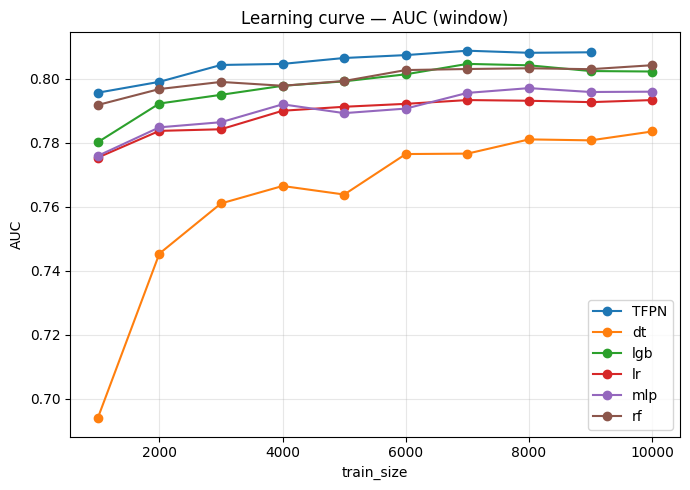

In [17]:
metric_to_plot = "AUC"   # cambia con la metrica desiderata

fig = plot_learning_curves(learning_curve_store, tag, metrics=metric_to_plot)
plt.show()

In [12]:
# Salva le learning curve su file: un'immagine per metrica + i dati grezzi in CSV.
lc_outdir = "img"
os.makedirs(lc_outdir, exist_ok=True)

metrics_to_save = ["F1", "AUC", "precision", "recall", "accuracy",
                   "F1_val", "F1_train", "accuracy_train", "average_precision"]

# 1) Un chart per metrica (PNG ad alta risoluzione).
# for m in metrics_to_save:
#     fig = plot_learning_curves(learning_curve_store, tag, metrics=m)
#     fig.savefig(os.path.join(lc_outdir, f"learning_curve_{tag}_{m}.png"),
#                 dpi=300, bbox_inches="tight")
#     plt.close(fig)

# 2) Dati grezzi in CSV (per ricostruire/confrontare i chart in seguito).
rows = [
    {"model_type": model_type, "tag": t, "train_size": train_size, **vals}
    for (model_type, t, train_size), vals in learning_curve_store.items()
    if t == tag
]
df_lc = pd.DataFrame(rows).sort_values(["model_type", "train_size"])
csv_path = os.path.join(lc_outdir, f"learning_curves_{tag}.csv")
df_lc.to_csv(csv_path, index=False)

print(f"Salvati {len(metrics_to_save)} chart in '{lc_outdir}/' e i dati ({len(df_lc)} righe) in '{csv_path}'")


Salvati 9 chart in 'img/' e i dati (59 righe) in 'img/learning_curves_window.csv'
